# Results: `output3`

This is a **full multidimensional** run notebook (typically **K=69**). Cross-model LOO compares this folder to **`../naive_output/`**.

Structure is **identical** across `output`, `output2`, `output3`, and `naive_output` (same sections, plots, and tables); only this directory’s CSVs and `IS_BASELINE_NAIVE` differ.

Run all cells, or execute via:

`jupyter nbconvert --to notebook --execute results.ipynb --output results_executed.ipynb`

**Kernel:** needs `pandas`, `numpy`, `matplotlib`, `pyarrow` (skill names from parquet). Optional: `scipy` (HMC normal overlay on VI densities), `arviz` (PSIS-LOO), `seaborn` (styling).

**Update** `OBSERVED_RESPONSE_MEAN` in the next cell if your training sample differs.


Optional — uncomment if imports fail in your Jupyter kernel:

```python
%pip install -q pandas numpy matplotlib pyarrow scipy arviz seaborn
```


In [1]:
# --- Manual config (update after reruns / different sample) ---
# Observed mean accuracy for the *same* rows as the Stan fit (IsCorrect). Update if your sample changed.
OBSERVED_RESPONSE_MEAN = 0.3204


# Set True only in naive_output/results.ipynb (script sets this per target folder)
IS_BASELINE_NAIVE = False

# Only used when IS_BASELINE_NAIVE is True: which full-model artifact folder to compare against in LOO.
# Use "output", "output2", or "output3" to match the full run you care about.
FULL_RUN_FOR_LOO = "output"


## Setup & helpers


In [2]:
from __future__ import annotations

import ast
import csv
import json
import math
import re
import warnings
from pathlib import Path
from typing import Iterable

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[misc,assignment]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns  # type: ignore
    sns.set_theme(style="whitegrid")
except ModuleNotFoundError:
    plt.style.use("ggplot")

warnings.filterwarnings("ignore", category=UserWarning)

RESULTS_DIR = Path(".").resolve()
PROJECT_ROOT = RESULTS_DIR.parent
NAIVE_DIR = PROJECT_ROOT / "naive_output"

if IS_BASELINE_NAIVE:
    OTHER_LOO_DIR = (PROJECT_ROOT / FULL_RUN_FOR_LOO).resolve()
else:
    OTHER_LOO_DIR = NAIVE_DIR

EXPORT_DIR = RESULTS_DIR / "report_assets"
FIG_DIR = EXPORT_DIR / "figures"
TAB_DIR = EXPORT_DIR / "tables"
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)


def find_one(patterns: Iterable[str], *, base_dir: Path = RESULTS_DIR) -> Path:
    matches: list[Path] = []
    for pat in patterns:
        matches.extend(sorted(base_dir.glob(pat)))
    matches = sorted({m.resolve() for m in matches})
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly 1 match for {list(patterns)} in {base_dir}, got {len(matches)}: {matches}"
        )
    return matches[0]


def parse_skill_vocab_from_parquet(parquet_path: Path) -> dict[int, str]:
    import pyarrow.parquet as pq

    pf = pq.ParquetFile(str(parquet_path))
    md = pf.metadata.metadata or {}
    raw = md.get(b"skill_vocab_json")
    if raw is None:
        raise KeyError(f"Missing skill_vocab_json in {parquet_path}")
    s = raw.decode("utf-8", errors="ignore")
    try:
        obj = json.loads(s)
    except Exception:
        obj = ast.literal_eval(s)
    out: dict[int, str] = {}
    for k, v in obj.items():
        try:
            out[int(k)] = str(v)
        except Exception:
            continue
    return out


def infer_k_from_summary(summary_df: pd.DataFrame) -> int:
    idx = summary_df.index.astype(str)

    def max_index(prefix: str) -> int:
        m = 0
        for name in idx:
            if not name.startswith(prefix + "["):
                continue
            try:
                inner = name.split("[", 1)[1].split("]", 1)[0]
                k = int(inner.split(",")[0])
                m = max(m, k)
            except Exception:
                pass
        return m

    return max(max_index("mu_skill"), max_index("beta_age"), max_index("beta_gender"))


def extract_indexed_params(summary_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    rows = []
    pat = re.compile(r"^" + re.escape(prefix) + r"\[(\d+)\]$")
    for name in summary_df.index.astype(str):
        m = pat.match(name)
        if not m:
            continue
        i = int(m.group(1))
        r = summary_df.loc[name]
        rows.append(
            {
                "i": i,
                "mean": float(r["Mean"]),
                "sd": float(r["StdDev"]),
                "q05": float(r["5%"]),
                "q50": float(r["50%"]),
                "q95": float(r["95%"]),
                "neff": float(r["N_Eff"]),
                "rhat": float(r["R_hat"]),
            }
        )
    return pd.DataFrame(rows).sort_values("i").reset_index(drop=True)


def savefig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


## Load artifacts


In [3]:

summary_path = find_one(["nuts_mcmc_summary*.csv"])
vi_draws_path = find_one(["vi_draws_full*.csv"])
log_lik_path = find_one(["log_lik_draws*.csv"])
y_rep_path = find_one(["y_rep_draws*.csv"])
profiles_path = find_one(["target_student_profiles*.csv"])

summary_df = pd.read_csv(summary_path, index_col=0)
vi_draws_df = pd.read_csv(vi_draws_path)
K = infer_k_from_summary(summary_df)

if K == 69:
    vocab_parquet = PROJECT_ROOT / "processing" / "processed_data" / "full_task_all.parquet"
elif K == 9:
    vocab_parquet = PROJECT_ROOT / "processing_naive" / "processed_data" / "full_task_all_L1.parquet"
else:
    vocab_parquet = PROJECT_ROOT / "processing" / "processed_data" / "full_task_all.parquet"

skill_vocab = parse_skill_vocab_from_parquet(vocab_parquet)
skill_vocab_df = pd.DataFrame({"skill": range(1, K + 1)})
skill_vocab_df["skill_name"] = skill_vocab_df["skill"].map(skill_vocab).fillna(skill_vocab_df["skill"].astype(str))

print("K =", K, "| summary rows:", len(summary_df), "| VI draws:", len(vi_draws_df))


K = 69 | summary rows: 108818 | VI draws: 2000


## Convergence: R-hat & N_eff (all indexed params + globals)


,metric,n_parameters
0,$\hat{R} > 1.05$,55867
1,$\hat{R} > 1.01$,74450
2,$0.99 \leq \hat{R} \leq 1.01$,34368
3,$\hat{R} < 0.99$,0
4,$\hat{R}$ is NaN,0
5,Total rows in summary,108818


,metric,n_parameters
0,$N_{\mathrm{eff}} < 100$,66183
1,$N_{\mathrm{eff}} < 400$,72954
2,$400 \leq N_{\mathrm{eff}} \leq 1000$,32251
3,$N_{\mathrm{eff}} > 1000$,3613
4,$N_{\mathrm{eff}}$ is NaN or non-finite,0
5,Total rows in summary,108818


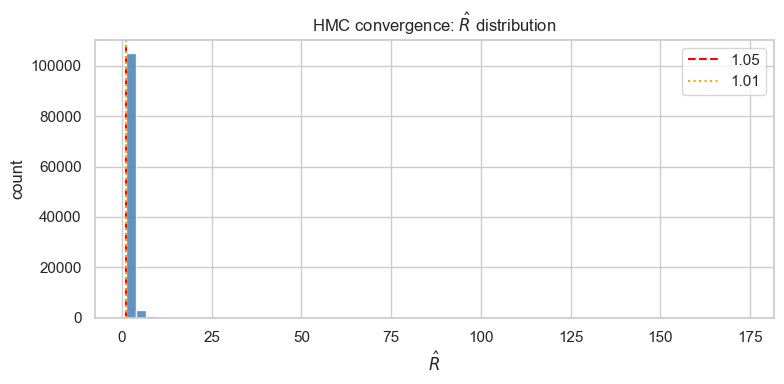

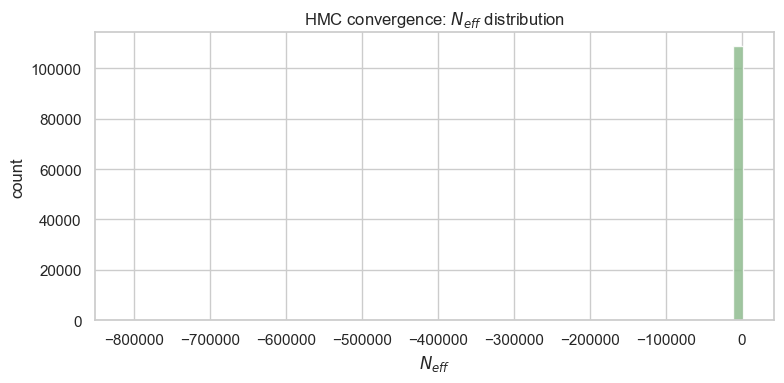

,param,Mean,StdDev,5%,50%,95%,N_Eff,R_hat
0,gamma_base,0.23453,0.05830,0.16790,0.29262,0.29264,1.01302,16.01002
1,gamma_fast_delta,0.04150,0.03523,0.01215,0.01872,0.11817,1.76709,1.39660
2,alpha,0.77050,0.17194,0.60000,0.85177,0.97917,1.01924,9.35399
3,beta_time,0.26184,0.68092,-0.41788,0.84318,0.99881,1.01114,26.12388
4,mu_log_time,5.32325,0.53622,4.78749,5.84031,5.86727,1.01015,128.47575
5,sigma_log_time,0.48042,0.48083,0.00000,0.94946,0.96638,1.01013,173.10228


,n_params,rhat_max,rhat_min,neff_median,neff_min
0,108818,173.10228,0.996661,10.08435,-810748.0


In [4]:

rhat = pd.to_numeric(summary_df["R_hat"], errors="coerce")
neff = pd.to_numeric(summary_df["N_Eff"], errors="coerce")

rh = rhat.dropna()
rhat_bin_tbl = pd.DataFrame(
    [
        {"metric": r"$\hat{R} > 1.05$", "n_parameters": int((rh > 1.05).sum())},
        {"metric": r"$\hat{R} > 1.01$", "n_parameters": int((rh > 1.01).sum())},
        {"metric": r"$0.99 \leq \hat{R} \leq 1.01$", "n_parameters": int(((rh >= 0.99) & (rh <= 1.01)).sum())},
        {"metric": r"$\hat{R} < 0.99$", "n_parameters": int((rh < 0.99).sum())},
        {"metric": r"$\hat{R}$ is NaN", "n_parameters": int(rhat.isna().sum())},
        {"metric": "Total rows in summary", "n_parameters": int(len(summary_df))},
    ]
)
rhat_bin_tbl.to_csv(TAB_DIR / "convergence_rhat_bin_counts.csv", index=False)
display(rhat_bin_tbl)

ef = neff.replace([np.inf, -np.inf], np.nan).dropna()
neff_bin_tbl = pd.DataFrame(
    [
        {"metric": r"$N_{\mathrm{eff}} < 100$", "n_parameters": int((ef < 100).sum())},
        {"metric": r"$N_{\mathrm{eff}} < 400$", "n_parameters": int((ef < 400).sum())},
        {"metric": r"$400 \leq N_{\mathrm{eff}} \leq 1000$", "n_parameters": int(((ef >= 400) & (ef <= 1000)).sum())},
        {"metric": r"$N_{\mathrm{eff}} > 1000$", "n_parameters": int((ef > 1000).sum())},
        {"metric": r"$N_{\mathrm{eff}}$ is NaN or non-finite", "n_parameters": int(len(summary_df) - len(ef))},
        {"metric": "Total rows in summary", "n_parameters": int(len(summary_df))},
    ]
)
neff_bin_tbl.to_csv(TAB_DIR / "convergence_neff_bin_counts.csv", index=False)
display(neff_bin_tbl)

plt.figure(figsize=(8, 4))
plt.hist(rhat.dropna(), bins=60, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(1.05, color="red", ls="--", label="1.05")
plt.axvline(1.01, color="orange", ls=":", label="1.01")
plt.xlabel(r"$\hat{R}$")
plt.ylabel("count")
plt.title("HMC convergence: " + r"$\hat{R}$" + " distribution")
plt.legend()
savefig(FIG_DIR / "convergence_rhat_hist.png")

plt.figure(figsize=(8, 4))
neff_clean = neff.replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(neff_clean, bins=60, color="darkseagreen", edgecolor="white", alpha=0.85)
plt.xlabel(r"$N_{eff}$")
plt.ylabel("count")
plt.title(r"HMC convergence: $N_{eff}$ distribution")
savefig(FIG_DIR / "convergence_neff_hist.png")

key_params = [
    p
    for p in ["gamma_base", "gamma_fast_delta", "alpha", "beta_time", "mu_log_time", "sigma_log_time"]
    if p in summary_df.index
]
key_tbl = summary_df.loc[key_params, ["Mean", "StdDev", "5%", "50%", "95%", "N_Eff", "R_hat"]].reset_index(names="param")
key_tbl.to_csv(TAB_DIR / "convergence_key_parameters.csv", index=False)
display(key_tbl)

diag = pd.DataFrame(
    [
        {
            "n_params": len(summary_df),
            "rhat_max": float(rhat.max(skipna=True)),
            "rhat_min": float(rhat.min(skipna=True)),
            "neff_median": float(neff.median(skipna=True)),
            "neff_min": float(neff.replace([np.inf, -np.inf], np.nan).min(skipna=True)),
        }
    ]
)
diag.to_csv(TAB_DIR / "convergence_summary.csv", index=False)
display(diag)


## HMC vs VI: table + density overlays


,param,hmc_mean,hmc_sd,hmc_q05,hmc_q50,hmc_q95,vi_q05,vi_q50,vi_q95,vi_mean,vi_sd,mean_delta_vi_minus_hmc,sd_ratio_vi_over_hmc
0,gamma_base,0.23453,0.05830,0.16790,0.29262,0.29264,0.187127,0.192873,0.198615,0.192885,0.003515,-0.041645,0.060292
1,alpha,0.77050,0.17194,0.60000,0.85177,0.97917,0.713432,0.728403,0.743512,0.728352,0.009114,-0.042148,0.053007
2,beta_time,0.26184,0.68092,-0.41788,0.84318,0.99881,0.851891,0.940337,1.027839,0.940369,0.054711,0.678529,0.080349
3,mu_log_time,5.32325,0.53622,4.78749,5.84031,5.86727,5.823929,5.832725,5.842090,5.832766,0.005591,0.509516,0.010426
4,sigma_log_time,0.48042,0.48083,0.00000,0.94946,0.96638,0.981028,0.987725,0.994266,0.987735,0.003987,0.507315,0.008291


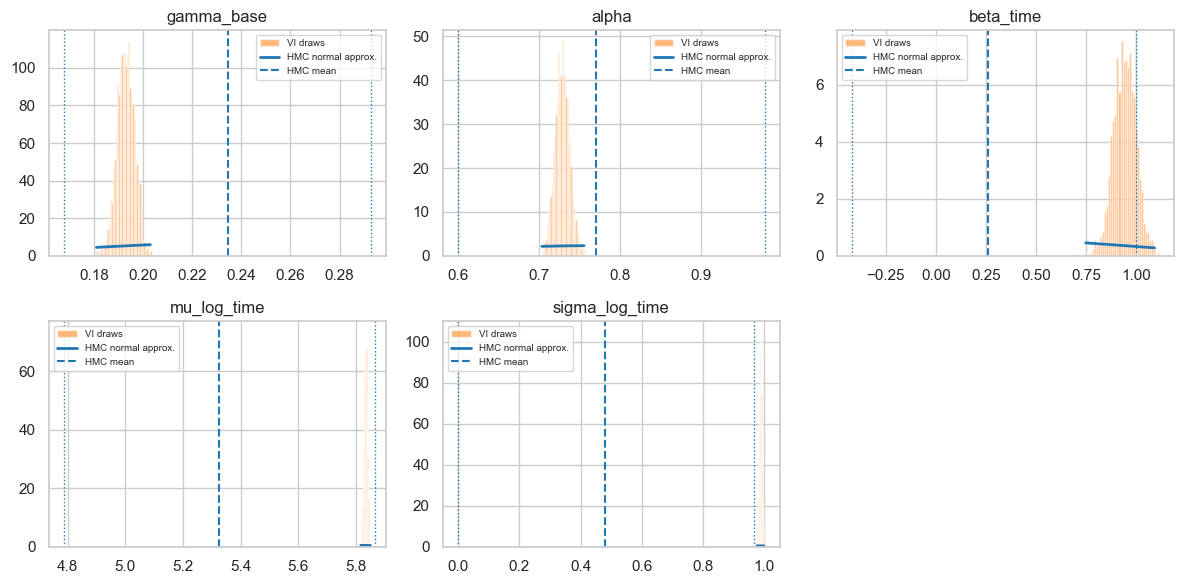

In [5]:

globals_present = [
    c for c in ["gamma_base", "alpha", "beta_time", "mu_log_time", "sigma_log_time"] if c in vi_draws_df.columns
]
hmc = summary_df.loc[globals_present, ["Mean", "StdDev", "5%", "50%", "95%"]].copy()
hmc.columns = ["hmc_mean", "hmc_sd", "hmc_q05", "hmc_q50", "hmc_q95"]

vi_q = vi_draws_df[globals_present].quantile([0.05, 0.5, 0.95]).T
vi_q.columns = ["vi_q05", "vi_q50", "vi_q95"]
vi_q["vi_mean"] = vi_draws_df[globals_present].mean().values
vi_q["vi_sd"] = vi_draws_df[globals_present].std(ddof=1).values

cmp = hmc.join(vi_q, how="left").reset_index(names="param")
cmp["mean_delta_vi_minus_hmc"] = cmp["vi_mean"] - cmp["hmc_mean"]
cmp["sd_ratio_vi_over_hmc"] = cmp["vi_sd"] / cmp["hmc_sd"].replace(0, np.nan)
cmp.to_csv(TAB_DIR / "hmc_vs_vi_globals_table.csv", index=False)
display(cmp)

try:
    from scipy import stats  # type: ignore
except ImportError:
    stats = None

n_params = len(globals_present)
fig, axes = plt.subplots(2, (n_params + 1) // 2, figsize=(4 * max(2, (n_params + 1) // 2), 6))
axes = np.atleast_1d(axes).ravel()
for ax, p in zip(axes, globals_present):
    xs = vi_draws_df[p].to_numpy(dtype=float)
    ax.hist(xs, bins=40, density=True, alpha=0.55, color="tab:orange", label="VI draws")
    if stats is not None:
        lo, hi = np.quantile(xs, [0.001, 0.999])
        grid = np.linspace(lo, hi, 300)
        ax.plot(
            grid,
            stats.norm.pdf(grid, loc=float(hmc.loc[p, "hmc_mean"]), scale=max(float(hmc.loc[p, "hmc_sd"]), 1e-6)),
            color="tab:blue",
            lw=2,
            label="HMC normal approx.",
        )
    ax.axvline(float(hmc.loc[p, "hmc_mean"]), color="tab:blue", ls="--", lw=1.5, label="HMC mean")
    ax.axvline(float(hmc.loc[p, "hmc_q05"]), color="tab:blue", ls=":", lw=1)
    ax.axvline(float(hmc.loc[p, "hmc_q95"]), color="tab:blue", ls=":", lw=1)
    ax.set_title(p)
    ax.legend(fontsize=7)
for j in range(len(globals_present), len(axes)):
    axes[j].set_visible(False)
savefig(FIG_DIR / "hmc_vs_vi_density_overlays.png")


## Skill structure: mu_skill & sigma_skill (all K, 90% CI)


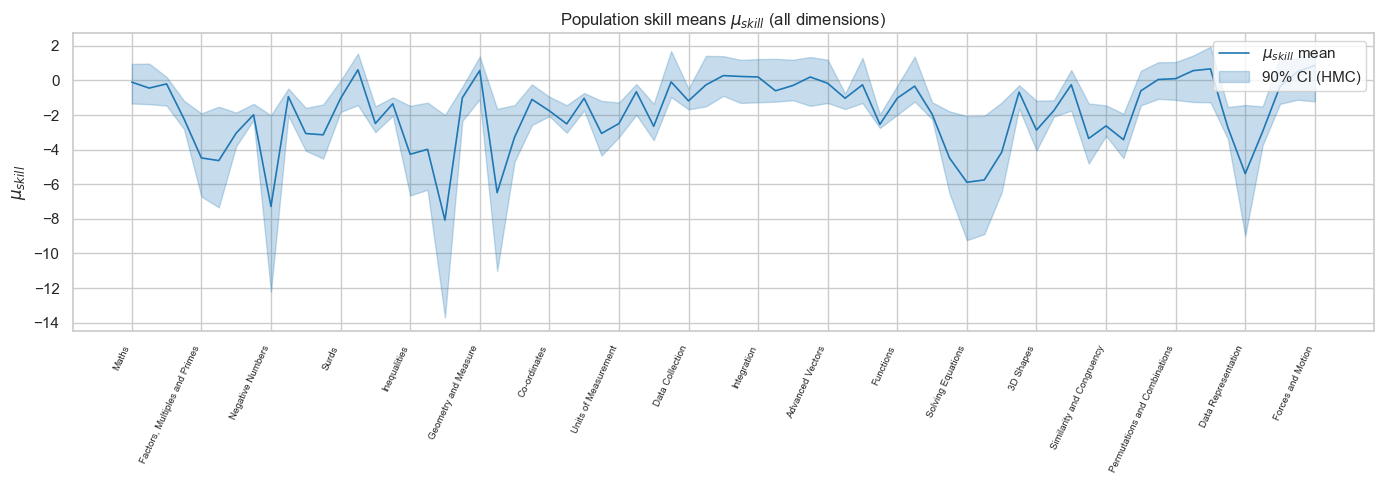

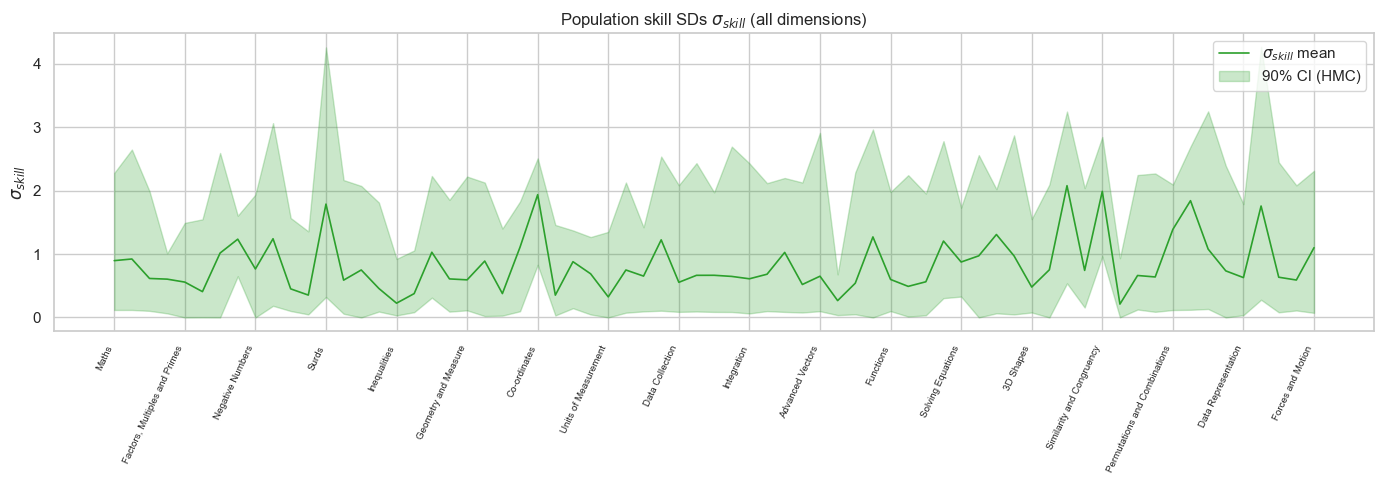

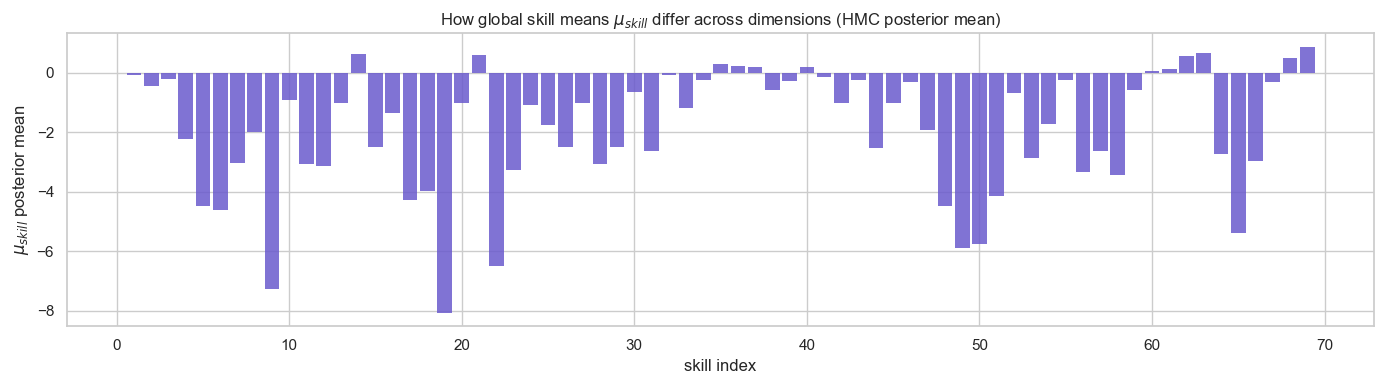

In [6]:

mu_df = extract_indexed_params(summary_df, "mu_skill").merge(skill_vocab_df, left_on="i", right_on="skill", how="left")
sig_df = extract_indexed_params(summary_df, "sigma_skill").merge(skill_vocab_df, left_on="i", right_on="skill", how="left")
mu_df.to_csv(TAB_DIR / "mu_skill_all.csv", index=False)
sig_df.to_csv(TAB_DIR / "sigma_skill_all.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = mu_df["i"].values
ax.plot(x, mu_df["mean"], color="tab:blue", lw=1.2, label=r"$\mu_{skill}$ mean")
ax.fill_between(x, mu_df["q05"], mu_df["q95"], color="tab:blue", alpha=0.25, label="90% CI (HMC)")
ax.set_xticks(x[:: max(1, K // 15)])
ax.set_xticklabels(mu_df["skill_name"].astype(str).values[:: max(1, K // 15)], rotation=65, ha="right", fontsize=7)
ax.set_ylabel(r"$\mu_{skill}$")
ax.set_title(r"Population skill means $\mu_{skill}$ (all dimensions)")
ax.legend(loc="upper right")
savefig(FIG_DIR / "skill_structure_mu_skill.png")

fig, ax = plt.subplots(figsize=(14, 5))
x = sig_df["i"].values
ax.plot(x, sig_df["mean"], color="tab:green", lw=1.2, label=r"$\sigma_{skill}$ mean")
ax.fill_between(x, sig_df["q05"], sig_df["q95"], color="tab:green", alpha=0.25, label="90% CI (HMC)")
ax.set_xticks(x[:: max(1, K // 15)])
ax.set_xticklabels(sig_df["skill_name"].astype(str).values[:: max(1, K // 15)], rotation=65, ha="right", fontsize=7)
ax.set_ylabel(r"$\sigma_{skill}$")
ax.set_title(r"Population skill SDs $\sigma_{skill}$ (all dimensions)")
ax.legend(loc="upper right")
savefig(FIG_DIR / "skill_structure_sigma_skill.png")

# Global means differ: bar chart of mu_skill means (ordered by skill index)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(mu_df["i"], mu_df["mean"], width=0.85, color="slateblue", edgecolor="none", alpha=0.85)
ax.set_xlabel("skill index")
ax.set_ylabel(r"$\mu_{skill}$ posterior mean")
ax.set_title(r"How global skill means $\mu_{skill}$ differ across dimensions (HMC posterior mean)")
savefig(FIG_DIR / "skill_global_means_bar.png")


## Question difficulty


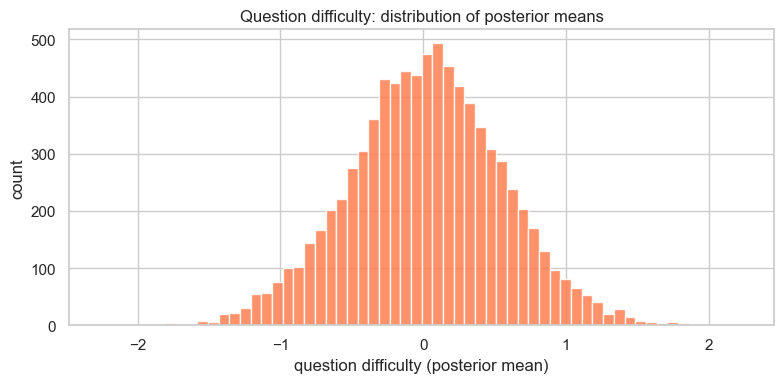

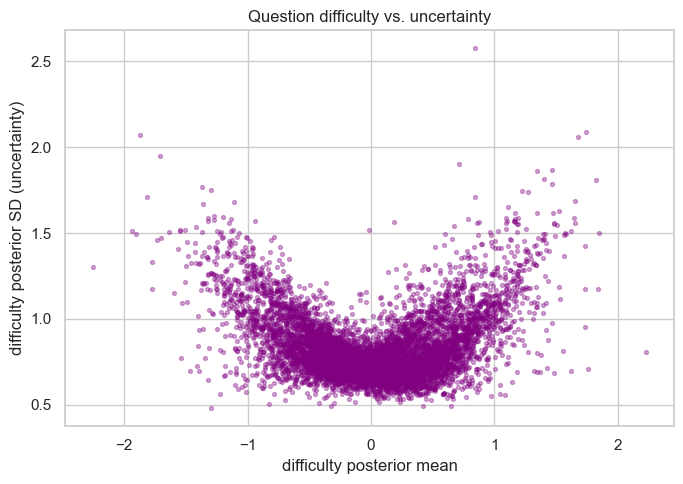

In [7]:

qdiff = extract_indexed_params(summary_df, "question_difficulty")
qdiff.to_csv(TAB_DIR / "question_difficulty_all.csv", index=False)

plt.figure(figsize=(8, 4))
plt.hist(qdiff["mean"], bins=60, color="coral", edgecolor="white", alpha=0.85)
plt.xlabel("question difficulty (posterior mean)")
plt.ylabel("count")
plt.title("Question difficulty: distribution of posterior means")
savefig(FIG_DIR / "question_difficulty_hist.png")

plt.figure(figsize=(7, 5))
plt.scatter(qdiff["mean"], qdiff["sd"], s=8, alpha=0.35, c="purple")
plt.xlabel("difficulty posterior mean")
plt.ylabel("difficulty posterior SD (uncertainty)")
plt.title("Question difficulty vs. uncertainty")
savefig(FIG_DIR / "question_difficulty_vs_uncertainty.png")


## PPC: per-draw mean accuracy vs observed


,n_draws,ppc_mean_of_draw_means,ppc_sd,observed_response_mean,abs_diff
0,600,0.320912,0.004098,0.3204,0.000512


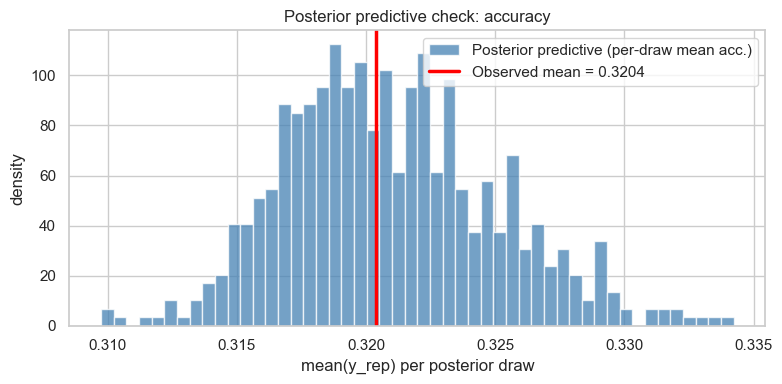

In [8]:

def stream_row_means_yrep(csv_path: Path) -> np.ndarray:
    means = []
    with csv_path.open("r", encoding="utf-8", errors="ignore", newline="") as fh:
        reader = csv.reader(fh)
        header = next(reader)
        if not header or not header[0].startswith("y_rep["):
            raise ValueError(f"Bad y_rep header: {header[:3]}")
        for row in reader:
            if not row:
                continue
            arr = np.asarray(row, dtype=np.float64)
            means.append(float(arr.mean()))
    return np.asarray(means, dtype=float)

ppc_draw_means = stream_row_means_yrep(y_rep_path)
ppc_tbl = pd.DataFrame(
    {
        "n_draws": [len(ppc_draw_means)],
        "ppc_mean_of_draw_means": [float(np.mean(ppc_draw_means))],
        "ppc_sd": [float(np.std(ppc_draw_means, ddof=1))],
        "observed_response_mean": [float(OBSERVED_RESPONSE_MEAN)],
        "abs_diff": [float(abs(np.mean(ppc_draw_means) - OBSERVED_RESPONSE_MEAN))],
    }
)
ppc_tbl.to_csv(TAB_DIR / "ppc_accuracy_vs_observed.csv", index=False)
display(ppc_tbl)

plt.figure(figsize=(8, 4))
plt.hist(ppc_draw_means, bins=50, density=True, color="steelblue", alpha=0.75, edgecolor="white", label="Posterior predictive (per-draw mean acc.)")
plt.axvline(OBSERVED_RESPONSE_MEAN, color="red", lw=2.5, label=f"Observed mean = {OBSERVED_RESPONSE_MEAN:.4f}")
plt.xlabel("mean(y_rep) per posterior draw")
plt.ylabel("density")
plt.title("Posterior predictive check: accuracy")
plt.legend()
savefig(FIG_DIR / "ppc_accuracy_vs_observed.png")


## Student profiles: bar + pairwise scatter


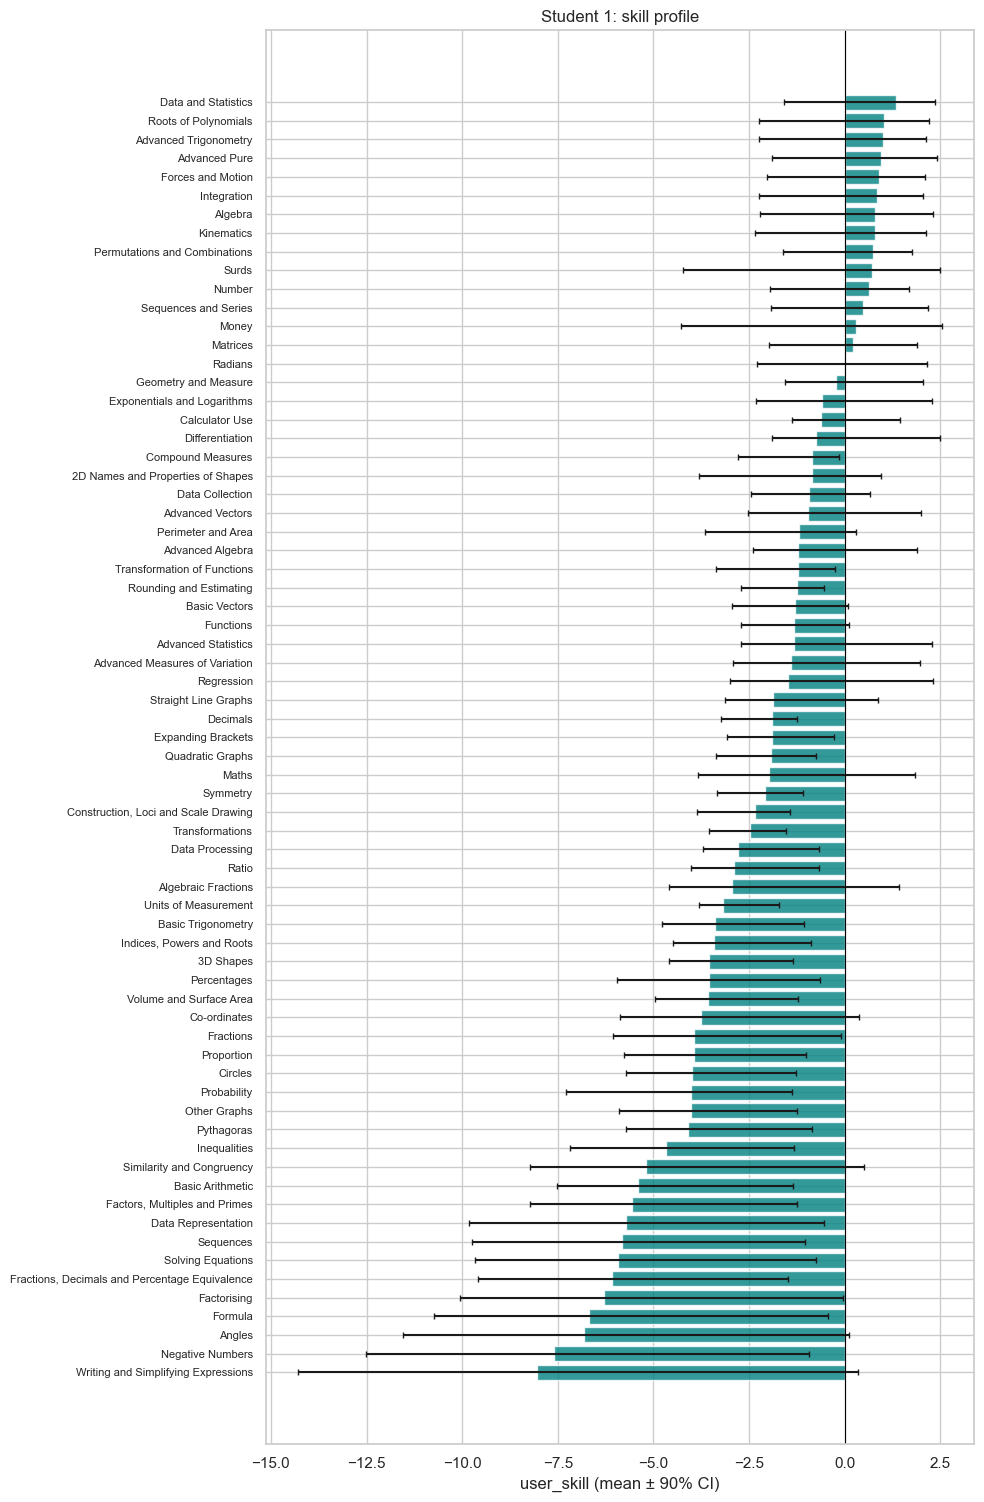

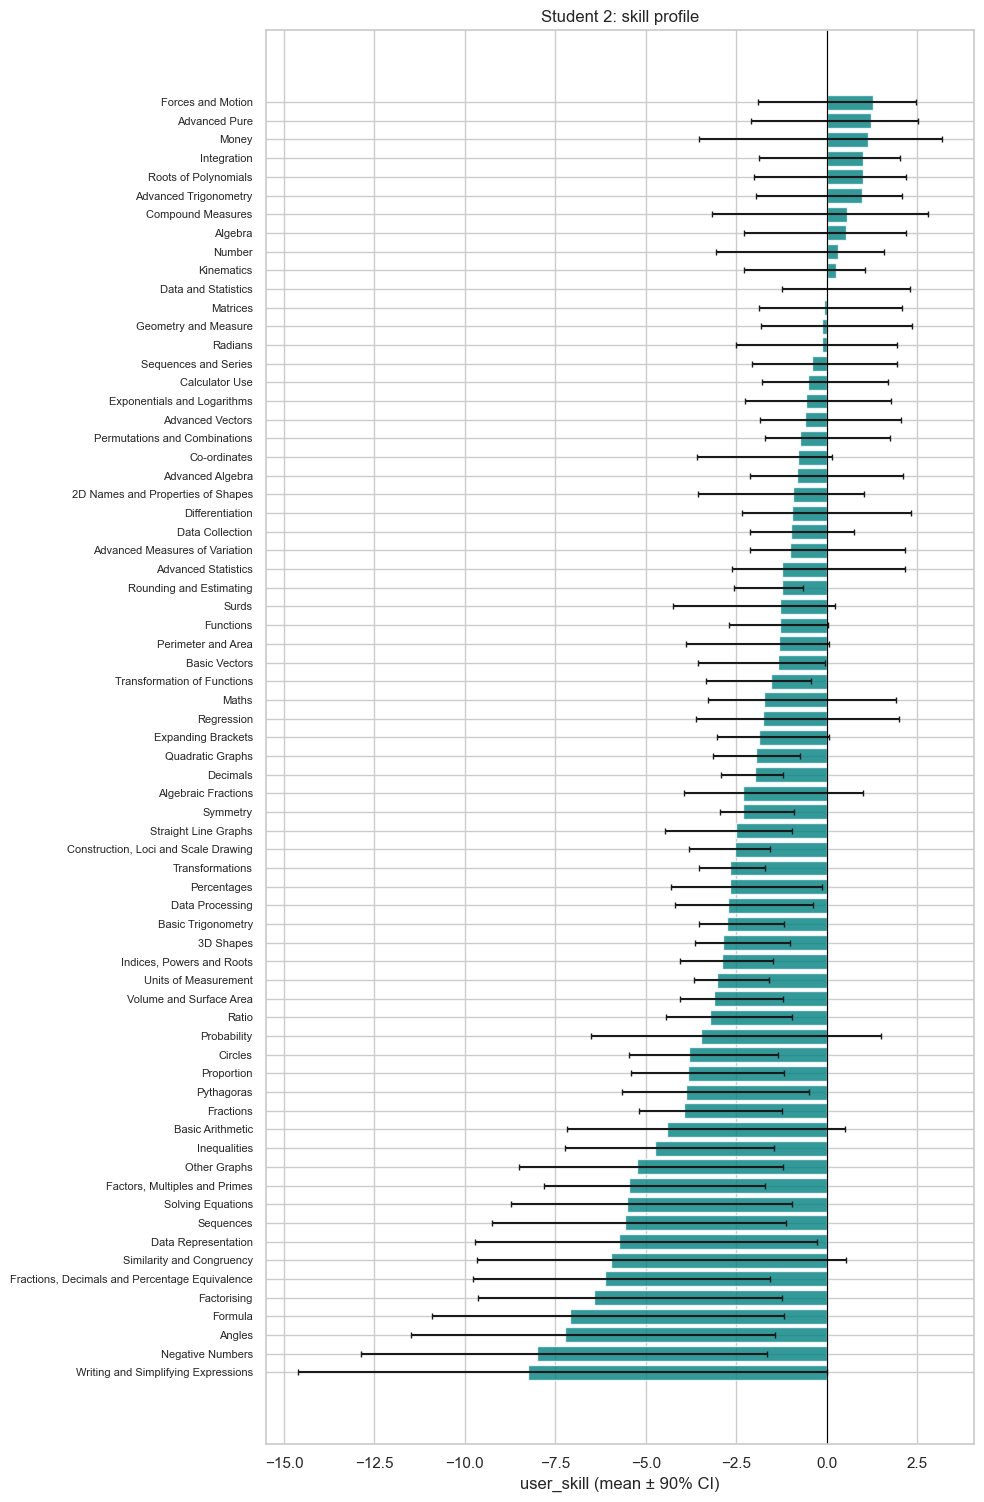

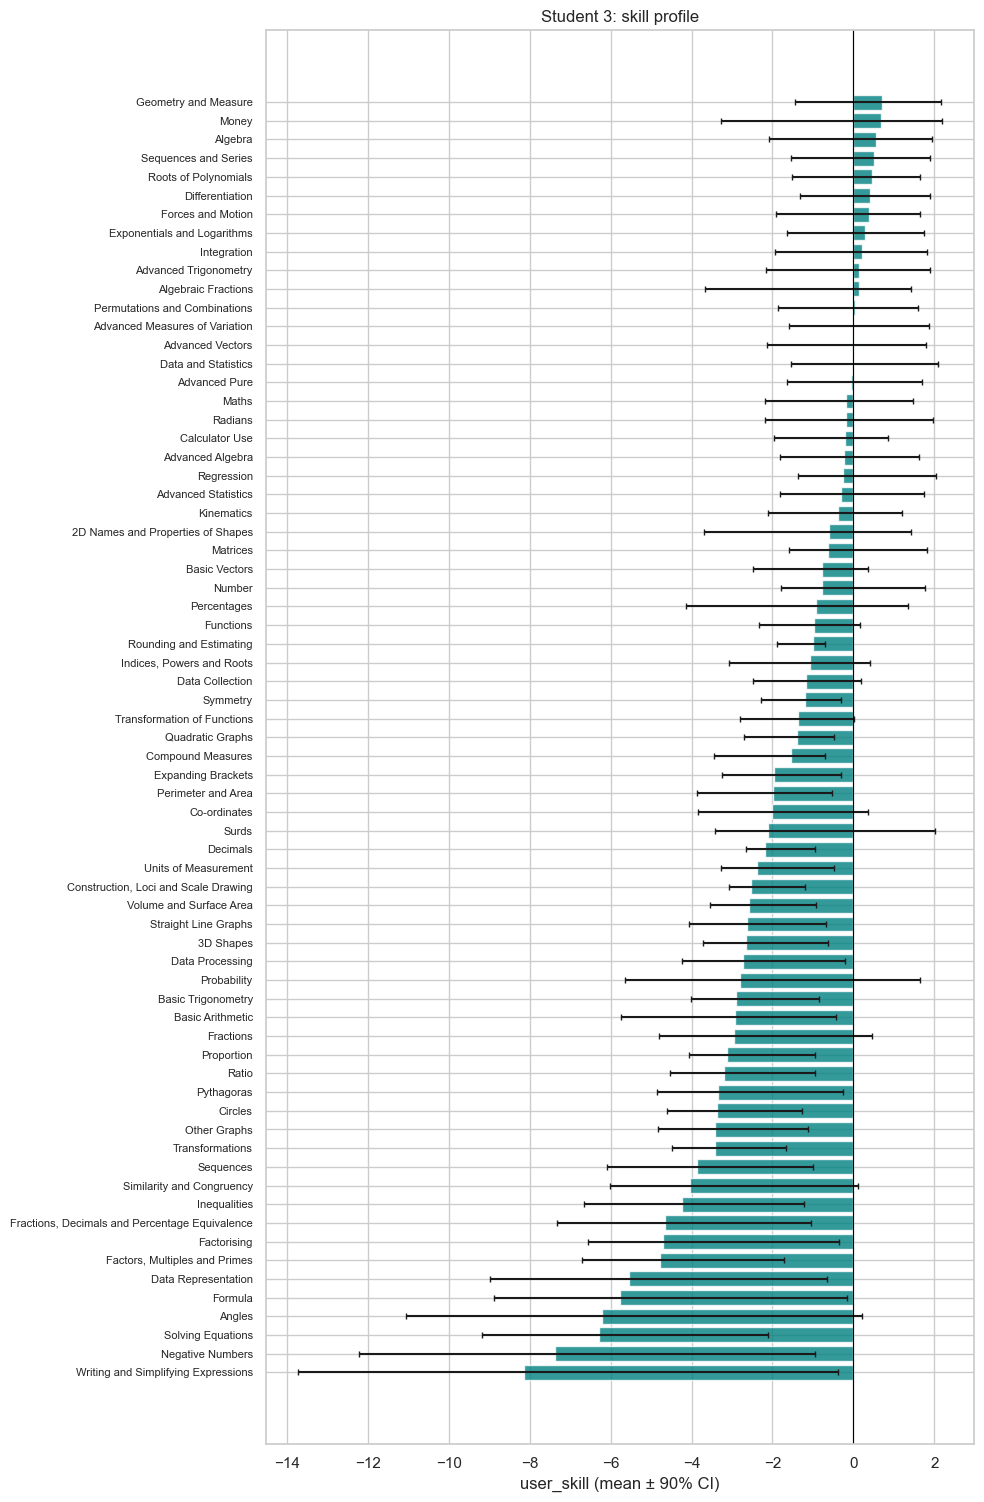

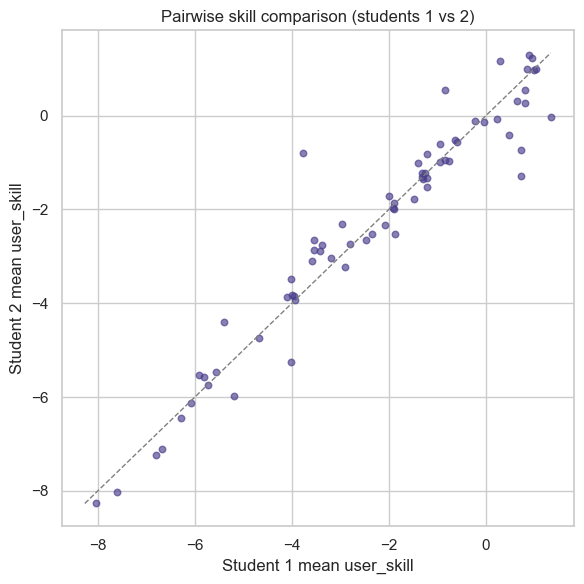

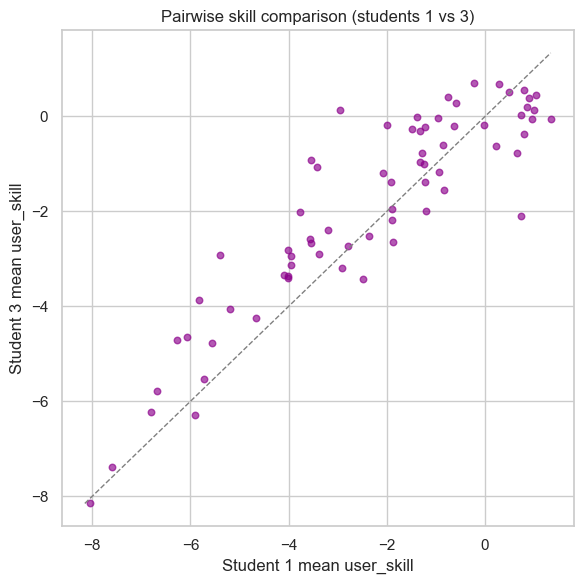

In [9]:

prof_raw = pd.read_csv(profiles_path)
pat = re.compile(r'^"?user_skill\[(\d+),(\d+)\]"?$')
rows = []
for col in prof_raw.columns:
    m = pat.match(str(col).strip())
    if not m:
        continue
    student, skill = int(m.group(1)), int(m.group(2))
    vals = prof_raw[col].to_numpy(dtype=float)
    rows.append(
        {
            "student": student,
            "skill": skill,
            "mean": float(np.mean(vals)),
            "q05": float(np.quantile(vals, 0.05)),
            "q95": float(np.quantile(vals, 0.95)),
        }
    )
prof = pd.DataFrame(rows).merge(skill_vocab_df, on="skill", how="left")

for sid in sorted(prof["student"].unique()):
    sub = prof[prof["student"] == sid].sort_values("mean")
    plt.figure(figsize=(10, max(4, 0.22 * len(sub))))
    y = np.arange(len(sub))
    plt.barh(y, sub["mean"], xerr=[sub["mean"] - sub["q05"], sub["q95"] - sub["mean"]], color="teal", alpha=0.8, capsize=2)
    plt.yticks(y, sub["skill_name"].astype(str), fontsize=8 if K > 20 else 9)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("user_skill (mean ± 90% CI)")
    plt.title(f"Student {sid}: skill profile")
    savefig(FIG_DIR / f"student{sid}_profile_bars.png")

# Pairwise scatter: student 1 vs 2 means per skill
pivot = prof.pivot_table(index="skill", columns="student", values="mean", aggfunc="first")
pivot = pivot.join(skill_vocab_df.set_index("skill")[["skill_name"]], how="left")
stud_cols = [c for c in pivot.columns if c != "skill_name"]
if 1 in stud_cols and 2 in stud_cols:
    plt.figure(figsize=(6, 6))
    plt.scatter(pivot[1], pivot[2], s=22, alpha=0.65, c="darkslateblue")
    mn = min(pivot[1].min(), pivot[2].min())
    mx = max(pivot[1].max(), pivot[2].max())
    plt.plot([mn, mx], [mn, mx], ls="--", c="gray", lw=1)
    plt.xlabel("Student 1 mean user_skill")
    plt.ylabel("Student 2 mean user_skill")
    plt.title("Pairwise skill comparison (students 1 vs 2)")
    savefig(FIG_DIR / "student_pairwise_1_vs_2.png")
if 1 in stud_cols and 3 in stud_cols:
    plt.figure(figsize=(6, 6))
    plt.scatter(pivot[1], pivot[3], s=22, alpha=0.65, c="darkmagenta")
    mn = min(pivot[1].min(), pivot[3].min())
    mx = max(pivot[1].max(), pivot[3].max())
    plt.plot([mn, mx], [mn, mx], ls="--", c="gray", lw=1)
    plt.xlabel("Student 1 mean user_skill")
    plt.ylabel("Student 3 mean user_skill")
    plt.title("Pairwise skill comparison (students 1 vs 3)")
    savefig(FIG_DIR / "student_pairwise_1_vs_3.png")

prof_summary = prof.groupby("student").agg(mean_of_means=("mean", "mean")).reset_index()
prof_summary.to_csv(TAB_DIR / "student_profiles_summary.csv", index=False)


## LOO-CV: per-obs log predictive density + optional PSIS-LOO


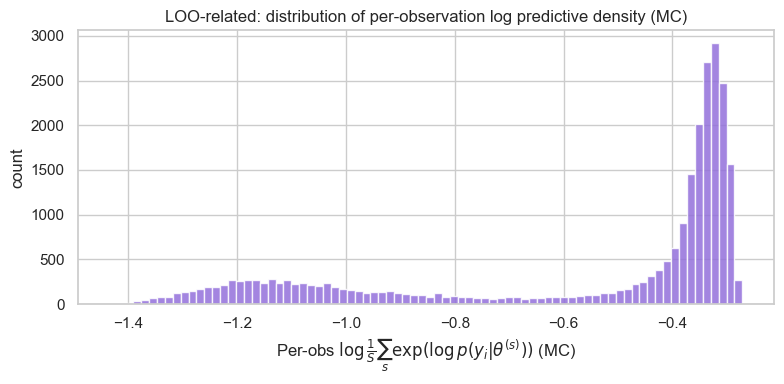

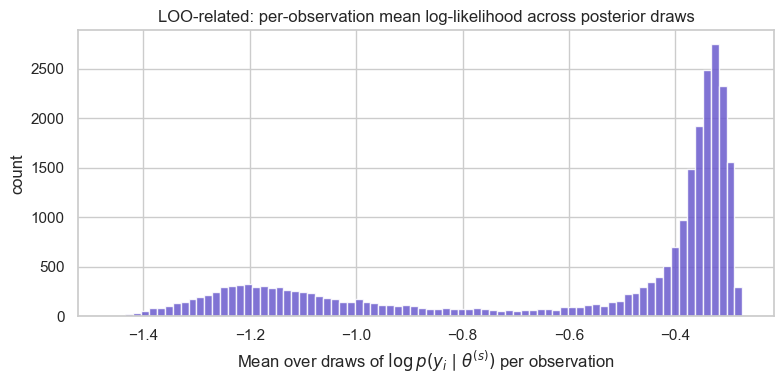

PSIS-LOO (arviz) skipped: ModuleNotFoundError No module named 'arviz'


,model,n_obs,elpd_mc_sum
0,this,25312,-14334.600795
1,other,10000,-5856.737077


In [10]:

def load_log_lik_matrix(csv_path: Path) -> tuple[np.ndarray, int]:
    """Return log_lik as (n_draws, n_obs) float32."""
    df = pd.read_csv(csv_path, dtype=np.float32)
    cols = [c for c in df.columns if str(c).startswith("log_lik[")]
    if not cols:
        cols = list(df.columns)
    mat = df[cols].to_numpy(dtype=np.float32, copy=False)
    return mat, mat.shape[1]


log_lik_mat, n_obs_ll = load_log_lik_matrix(log_lik_path)
# Per-observation log predictive density (Monte Carlo): log mean exp
logsum = np.logaddexp.reduce(log_lik_mat.astype(np.float64), axis=0)
lpd_mc = logsum - math.log(log_lik_mat.shape[0])
loo_tbl_mc = pd.DataFrame(
    {
        "metric": ["elpd_sum_mc", "elpd_per_obs_mc"],
        "value": [float(lpd_mc.sum()), float(lpd_mc.mean())],
    }
)
loo_tbl_mc.to_csv(TAB_DIR / "loo_mc_elpd.csv", index=False)

plt.figure(figsize=(8, 4))
plt.hist(lpd_mc, bins=80, color="mediumpurple", edgecolor="white", alpha=0.85)
plt.xlabel(r"Per-obs $\log \frac{1}{S}\sum_s \exp(\log p(y_i|\theta^{(s)}))$ (MC)")
plt.ylabel("count")
plt.title("LOO-related: distribution of per-observation log predictive density (MC)")
savefig(FIG_DIR / "loo_per_obs_lpd_hist.png")

mean_loglik_obs = np.mean(log_lik_mat.astype(np.float64), axis=0)
plt.figure(figsize=(8, 4))
plt.hist(mean_loglik_obs, bins=80, color="slateblue", edgecolor="white", alpha=0.85)
plt.xlabel(r"Mean over draws of $\log p(y_i \mid \theta^{(s)})$ per observation")
plt.ylabel("count")
plt.title("LOO-related: per-observation mean log-likelihood across posterior draws")
savefig(FIG_DIR / "loo_per_obs_mean_loglik_hist.png")

loo_psis_row = None
try:
    import arviz as az  # type: ignore

    ll_reshaped = log_lik_mat[np.newaxis, :, :].astype(np.float64)
    idata = az.from_dict(log_likelihood={"y": ll_reshaped})
    loo = az.loo(idata, var_name="y", pointwise=True)
    elpd_loo = float(getattr(loo, "elpd_loo", np.nan))
    se = float(getattr(loo, "se", np.nan))
    loo_psis_row = pd.DataFrame(
        [{"elpd_loo": elpd_loo, "se": se, "elpd_loo_per_obs": elpd_loo / n_obs_ll, "n_obs": n_obs_ll}]
    )
    loo_psis_row.to_csv(TAB_DIR / "loo_psis_arviz.csv", index=False)
    display(loo_psis_row)
except Exception as e:
    print("PSIS-LOO (arviz) skipped:", type(e).__name__, e)

# Compare full vs naive ELPD (same n_obs required for difference in sum)
other_ll = find_one(["log_lik_draws*.csv"], base_dir=OTHER_LOO_DIR)
log_lik_other, n_other = load_log_lik_matrix(other_ll)
if n_other != n_obs_ll:
    print("Warning: log_lik column counts differ:", n_obs_ll, "vs", n_other, "(LOO comparison sum not comparable)")
    cross = pd.DataFrame(
        [
            {"model": "this", "n_obs": n_obs_ll, "elpd_mc_sum": float(lpd_mc.sum())},
            {"model": "other", "n_obs": n_other, "elpd_mc_sum": float((np.logaddexp.reduce(log_lik_other.astype(np.float64), axis=0) - math.log(log_lik_other.shape[0])).sum())},
        ]
    )
else:
    lpd_other = np.logaddexp.reduce(log_lik_other.astype(np.float64), axis=0) - math.log(log_lik_other.shape[0])
    cross = pd.DataFrame(
        [
            {
                "model": "this_run",
                "folder": RESULTS_DIR.name,
                "elpd_mc_sum": float(lpd_mc.sum()),
                "elpd_mc_per_obs": float(lpd_mc.mean()),
            },
            {
                "model": "other_run",
                "folder": OTHER_LOO_DIR.name,
                "elpd_mc_sum": float(lpd_other.sum()),
                "elpd_mc_per_obs": float(lpd_other.mean()),
            },
        ]
    )
    cross["delta_this_minus_other"] = cross.loc[0, "elpd_mc_sum"] - cross.loc[1, "elpd_mc_sum"]
cross.to_csv(TAB_DIR / "loo_cross_model_mc.csv", index=False)
display(cross)


## Report conclusions (copy-paste)


In [11]:

lines = []
lines.append("## Auto-generated report bullets")
lines.append(f"- Model: **{'naive (K=9)' if IS_BASELINE_NAIVE else 'full (K=69)'}** | fitted outputs folder: `{RESULTS_DIR.name}`")
lines.append(
    f"- Worst $\\hat{{R}}$: **{float(rhat.max(skipna=True)):.4f}** | "
    f"counts: >1.05 **{int((rh > 1.05).sum())}**, >1.01 **{int((rh > 1.01).sum())}**, "
    f"in [0.99,1.01] **{int(((rh >= 0.99) & (rh <= 1.01)).sum())}**"
)
lines.append(
    f"- $N_{{eff}}$: <100 **{int((ef < 100).sum())}**, <400 **{int((ef < 400).sum())}**, "
    f"in [400,1000] **{int(((ef >= 400) & (ef <= 1000)).sum())}**, >1000 **{int((ef > 1000).sum())}**"
)
lines.append(f"- Median $N_{{eff}}$: **{float(neff.median(skipna=True)):.1f}**")
lines.append(f"- PPC: posterior mean of per-draw mean accuracy **{float(np.mean(ppc_draw_means)):.4f}** vs observed **{OBSERVED_RESPONSE_MEAN:.4f}** (update `OBSERVED_RESPONSE_MEAN` if sample changed).")
lines.append(f"- LOO (MC log-mean-exp): total ELPD **{float(lpd_mc.sum()):.1f}** | per-obs **{float(lpd_mc.mean()):.4f}**")
if loo_psis_row is not None:
    lines.append(f"- PSIS-LOO (arviz): elpd_loo **{float(loo_psis_row.loc[0, 'elpd_loo']):.1f}** ± **{float(loo_psis_row.loc[0, 'se']):.2f}**")
lines.append(f"- Cross-model (MC): see `{TAB_DIR.name}/loo_cross_model_mc.csv` comparing `{RESULTS_DIR.name}` vs `{OTHER_LOO_DIR.name}`.")
sig_age = []
sig_gend = []
for pref, outl in [("beta_age", sig_age), ("beta_gender", sig_gend)]:
    for k in range(1, K + 1):
        name = f"{pref}[{k}]"
        if name not in summary_df.index:
            continue
        r = summary_df.loc[name]
        if np.sign(float(r["5%"])) == np.sign(float(r["95%"])):
            nm = skill_vocab.get(k, str(k))
            outl.append(f"{pref}[{k}]={nm}: mean={float(r['Mean']):.3f}")

lines.append("- Demographics (90% CI excludes 0): " + ("; ".join(sig_age[:5]) or "none") + (" ..." if len(sig_age) > 5 else ""))
lines.append("  Gender: " + ("; ".join(sig_gend[:5]) or "none"))

report_text = "\n".join(lines)
print(report_text)
(Path(TAB_DIR) / "report_conclusions.txt").write_text(report_text, encoding="utf-8")
print("\nWrote:", TAB_DIR / "report_conclusions.txt")


## Auto-generated report bullets
- Model: **full (K=69)** | fitted outputs folder: `output3`
- Worst $\hat{R}$: **173.1023** | counts: >1.05 **55867**, >1.01 **74450**, in [0.99,1.01] **34368**
- $N_{eff}$: <100 **66183**, <400 **72954**, in [400,1000] **32251**, >1000 **3613**
- Median $N_{eff}$: **10.1**
- PPC: posterior mean of per-draw mean accuracy **0.3209** vs observed **0.3204** (update `OBSERVED_RESPONSE_MEAN` if sample changed).
- LOO (MC log-mean-exp): total ELPD **-14334.6** | per-obs **-0.5663**
- Cross-model (MC): see `tables/loo_cross_model_mc.csv` comparing `output3` vs `naive_output`.
- Demographics (90% CI excludes 0): beta_age[4]=Decimals: mean=-1.055; beta_age[5]=Factors, Multiples and Primes: mean=-1.022; beta_age[8]=Indices, Powers and Roots: mean=-1.311; beta_age[10]=Percentages: mean=-1.965; beta_age[19]=Writing and Simplifying Expressions: mean=0.819 ...
  Gender: beta_gender[8]=Indices, Powers and Roots: mean=-0.205; beta_gender[44]=Basic Arithmetic: mean=-0.6